In [2]:
import pandas as pd

df = pd.read_csv("final_12k_log_transformed_papp_dataset.csv")

df.shape

(12290, 3)

# QSAR Modeling of Papp Permeability Dataset

This notebook develops machine learning models to predict molecular permeability using Morgan fingerprints and QSAR techniques.

The workflow includes:
- Molecular feature generation
- Train-test splitting
- Machine learning model development
- Model evaluation
- Prediction analysis

In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

RDLogger.DisableLog('rdApp.*')

## Morgan Fingerprint Generation

Morgan fingerprints are generated to convert molecular structures into numerical vectors suitable for QSAR modeling.

In [4]:
fingerprints = []

for smi in df['canonical_smiles']:

    mol = Chem.MolFromSmiles(smi)

    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol,
            radius=2,
            nBits=2048
        )

        fingerprints.append(np.array(fp))

X = np.array(fingerprints)

y = df['log_papp'].values

print(X.shape)
print(y.shape)

(12290, 2048)
(12290,)


## Train-Test Split

The dataset is divided into training and testing sets to evaluate the generalization performance of the QSAR model.

The training set is used for model learning, while the testing set is used to assess predictive performance on unseen molecules.80:20

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(9832, 2048)
(2458, 2048)


## Random Forest Regression Model

A Random Forest Regressor is trained as a baseline QSAR model using Morgan fingerprint descriptors to predict log-transformed permeability values.

In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred_rf = rf_model.predict(X_test)

In [10]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.5500612838187103
Random Forest R²: 0.588275936551077


## XGBoost Regression Model

An XGBoost Regressor is trained to improve nonlinear learning and predictive performance for permeability prediction using Morgan fingerprints.

In [11]:
from xgboost import XGBRegressor

In [12]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [13]:
y_pred_xgb = xgb_model.predict(X_test)

In [14]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost RMSE: 0.5703605264528662
XGBoost R²: 0.5573270176457568


## Prediction Performance Visualization

Predicted permeability values are compared against experimental values to evaluate QSAR model performance and prediction quality.

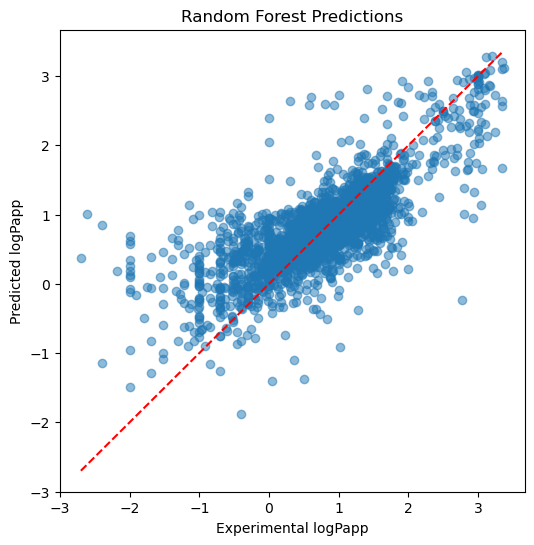

In [15]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Experimental logPapp")
plt.ylabel("Predicted logPapp")
plt.title("Random Forest Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Feature Importance Analysis

Feature importance analysis is performed to identify molecular fingerprint features contributing most strongly to permeability prediction.

In [16]:
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': range(len(importances)),
    'importance': importances
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

importance_df.head(10)

,feature,importance
389,389,0.016471
1693,1693,0.016262
1114,1114,0.015175
1444,1444,0.013333
807,807,0.012904
525,525,0.011276
1007,1007,0.011077
740,740,0.010697
975,975,0.009162
1844,1844,0.008795


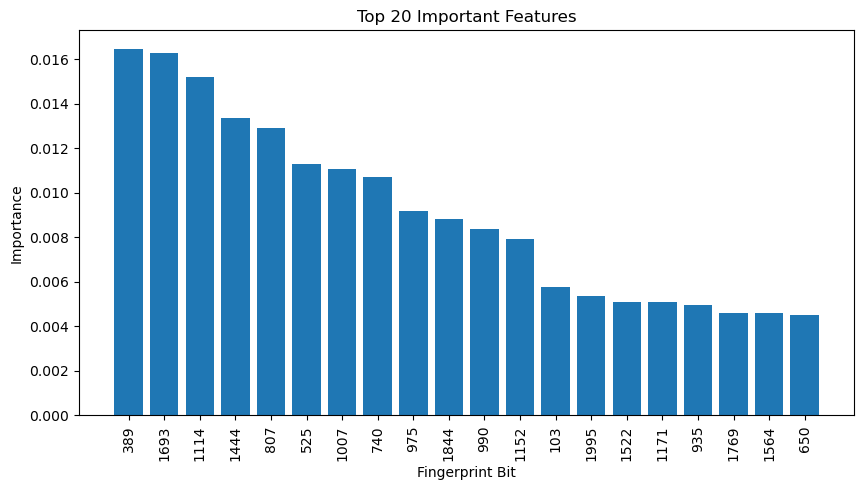

In [17]:
top_features = importance_df.head(20)

plt.figure(figsize=(10,5))

plt.bar(
    top_features['feature'].astype(str),
    top_features['importance']
)

plt.xticks(rotation=90)

plt.xlabel("Fingerprint Bit")
plt.ylabel("Importance")
plt.title("Top 20 Important Features")

plt.show()

## Experimental vs Predicted Distribution

The distribution of predicted permeability values is compared with experimental values to evaluate how well the model captures the overall property space.

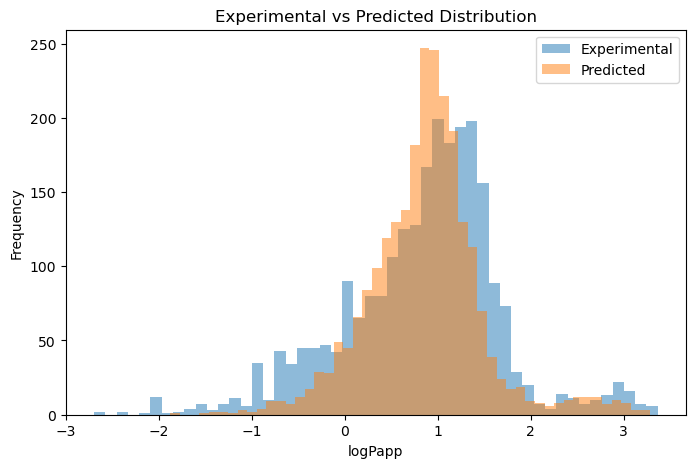

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    y_test,
    bins=50,
    alpha=0.5,
    label='Experimental'
)

plt.hist(
    y_pred_rf,
    bins=50,
    alpha=0.5,
    label='Predicted'
)

plt.xlabel("logPapp")
plt.ylabel("Frequency")
plt.title("Experimental vs Predicted Distribution")

plt.legend()

plt.show()

## LightGBM Regression Model

A LightGBM Regressor is evaluated to compare gradient boosting performance against Random Forest and XGBoost models for permeability prediction.

In [19]:
from lightgbm import LGBMRegressor

In [20]:
lgbm_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4046
[LightGBM] [Info] Number of data points in the train set: 9832, number of used features: 2023
[LightGBM] [Info] Start training from score 0.843078


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [21]:
y_pred_lgbm = lgbm_model.predict(X_test)

C:\Users\kiran\anaconda3\envs\chemtox_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [22]:
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))

r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM RMSE:", rmse_lgbm)
print("LightGBM R²:", r2_lgbm)

LightGBM RMSE: 0.554570822242595
LightGBM R²: 0.5814974326920945


## Support Vector Regression (SVR)

A Support Vector Regressor is evaluated as a classical QSAR machine learning algorithm for predicting molecular permeability.

Feature scaling is applied before SVR training to improve model performance.

In [23]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
svr_model = SVR(
    kernel='rbf',
    C=10,
    gamma='scale'
)

svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,10
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [26]:
y_pred_svr = svr_model.predict(X_test_scaled)

In [27]:
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

r2_svr = r2_score(y_test, y_pred_svr)

print("SVR RMSE:", rmse_svr)
print("SVR R²:", r2_svr)

SVR RMSE: 0.5457714804182006
SVR R²: 0.594672780621586


## Model Performance Comparison

The predictive performance of multiple machine learning models was compared using RMSE and R² metrics on the permeability dataset.

In [28]:
comparison_df = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'SVR'
    ],
    
    'RMSE': [
        rmse_rf,
        rmse_xgb,
        rmse_lgbm,
        rmse_svr
    ],
    
    'R2': [
        r2_rf,
        r2_xgb,
        r2_lgbm,
        r2_svr
    ]
})

comparison_df

,Model,RMSE,R2
0,Random Forest,0.550061,0.588276
1,XGBoost,0.570361,0.557327
2,LightGBM,0.554571,0.581497
3,SVR,0.545771,0.594673


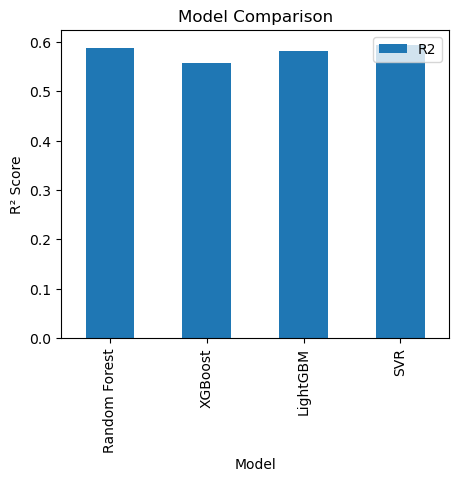

In [31]:
comparison_df.plot(
    x='Model',
    y='R2',
    kind='bar',
    figsize=(5,4)
)

plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.show()

# Final QSAR Benchmarking Conclusions

This study developed and benchmarked multiple machine learning models for predicting molecular permeability using Morgan fingerprint descriptors generated from molecular SMILES structures.

## Models Evaluated

The following regression algorithms were compared:

- Random Forest Regressor
- XGBoost Regressor
- LightGBM Regressor
- Support Vector Regressor (SVR)

## Key Findings

### 1. Molecular Feature Engineering
Morgan fingerprints successfully transformed molecular structures into 2048-dimensional numerical feature vectors suitable for QSAR modeling and machine learning analysis.

### 2. Model Benchmarking
Multiple machine learning approaches were evaluated to compare their ability to capture structure–permeability relationships within the dataset.

The benchmarking results demonstrated that model performance depends strongly on dataset characteristics and molecular representation.

### 3. Random Forest Performance
The Random Forest model provided strong baseline performance and demonstrated robust learning behavior on sparse molecular fingerprint features.

### 4. Gradient Boosting Models
Both XGBoost and LightGBM successfully captured nonlinear molecular relationships; however, their performance was slightly lower than Random Forest under the current parameter settings.

This highlights the importance of experimental benchmarking rather than assuming more complex models will always outperform simpler approaches.

### 5. Support Vector Regression (SVR)
The SVR model achieved the best overall predictive performance among the evaluated models.

This suggests that kernel-based nonlinear learning effectively captured the permeability-related structural patterns present within the dataset.

### 6. Prediction Quality
Prediction visualization and distribution analysis showed that the models captured the overall permeability landscape reasonably well, particularly within the central property range.

However, prediction accuracy decreased for extreme permeability compounds, which is a common challenge in QSAR regression tasks involving noisy ADMET datasets.

### 7. Feature Importance
Feature importance analysis demonstrated that permeability prediction depends on multiple distributed molecular fingerprint features rather than a single dominant structural fragment.

This reflects the multifactorial nature of molecular permeability behavior.

## Overall Conclusion

The benchmarking workflow successfully demonstrated the application of multiple machine learning algorithms for permeability prediction using cheminformatics descriptors.

The study established a complete QSAR modeling pipeline involving:
- molecular feature engineering
- machine learning benchmarking
- prediction evaluation
- model comparison
- feature importance analysis

Among the evaluated approaches, Support Vector Regression provided the best predictive performance on the current permeability dataset.

The results further demonstrate that classical machine learning algorithms can remain highly competitive for cheminformatics and QSAR applications.

This project provides a strong foundation for future work involving:
- hyperparameter optimization
- cross-validation
- hybrid descriptor modeling
- SHAP interpretation
- applicability domain analysis
- graph neural networks
- advanced deep learning approaches